# Capítulo 18 — Camada Limite Atmosférica: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | crescimento da camada de mistura ao longo do dia | `solve_ivp` |
| 2 | o perfil logarítmico do vento (e energia eólica) | NumPy |
| 3 | o espectro $-5/3$ de Kolmogorov num sinal turbulento | FFT |
| 4 | jato noturno: a oscilação inercial de Blackadar | `solve_ivp` |

Exercícios numéricos N1–N4 no fim; soluções em `cap18_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Cp, rho = 9.8, 1004.0, 1.1
Omega = 7.292e-5
kv = 0.4                                       # constante de von Kármán

## Caso 1 — A camada de mistura engolindo a manhã

O fluxo de calor da superfície (Cap. 3) corrói a estratificação noturna: modelo de *encroachment*,
$$\frac{dz_i}{dt} = \frac{F_H}{\rho\,C_p\,\gamma\,z_i}\quad\Rightarrow\quad z_i(t) = \sqrt{\frac{2}{\rho C_p\gamma}\int_0^t F_H\,dt'},$$
com $\gamma = \partial\theta/\partial z$ da atmosfera estável acima.

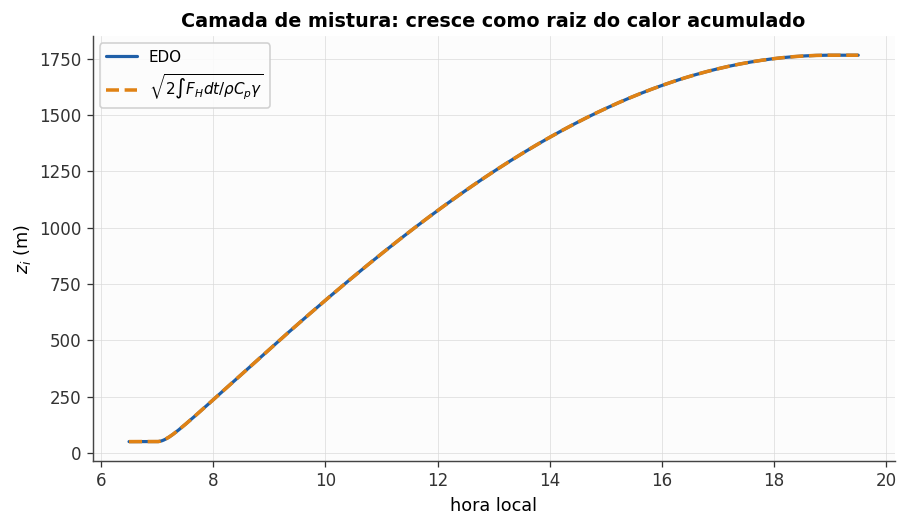

z_i no fim da tarde: 1765 m — o teto dos cumulus de bom tempo
(LCL do Cap. 4!) e a altura que mistura a poluicao da manha (Cap. 19).


In [2]:
gamma = 4.0e-3                                 # K/m acima da CL
FH_max = 250.0                                 # W/m² ao meio-dia

def FH(t):
    hora = t/3600 + 6.5                        # nasce as ~6h30
    return max(FH_max*np.sin(np.pi*(hora - 7)/12), 0.0) if 7 <= hora <= 19 else 0.0

def cresce(t, zi):
    return FH(t)/(rho*Cp*gamma*max(zi[0], 30.0))

t_eval = np.linspace(0, 13*3600, 400)
s = solve_ivp(cresce, [0, 13*3600], [50.0], t_eval=t_eval, rtol=1e-8)
acum = np.array([np.trapezoid([FH(tt) for tt in t_eval[:i+1]], t_eval[:i+1])
                 for i in range(t_eval.size)])
zi_teo = np.sqrt(np.maximum(2*acum/(rho*Cp*gamma), 0) + 50.0**2)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(t_eval/3600 + 6.5, s.y[0], color=CORES['azul'], lw=2, label='EDO')
ax.plot(t_eval/3600 + 6.5, zi_teo, '--', color=CORES['laranja'],
        label='$\\sqrt{2\\int F_H dt/\\rho C_p\\gamma}$')
ax.set(xlabel='hora local', ylabel='$z_i$ (m)',
       title='Camada de mistura: cresce como raiz do calor acumulado')
ax.legend()
plt.show()
print(f'z_i no fim da tarde: {s.y[0][-1]:.0f} m — o teto dos cumulus de bom tempo')
print('(LCL do Cap. 4!) e a altura que mistura a poluicao da manha (Cap. 19).')

## Caso 2 — O perfil logarítmico

Na camada superficial (10% inferior), tensão constante + análise dimensional dão
$$\bar u(z) = \frac{u_*}{k}\ln\frac{z}{z_0},$$
com $u_*$ a velocidade de atrito e $z_0$ a rugosidade (mar ~0,1 mm; grama ~1 cm; cidade ~1 m).

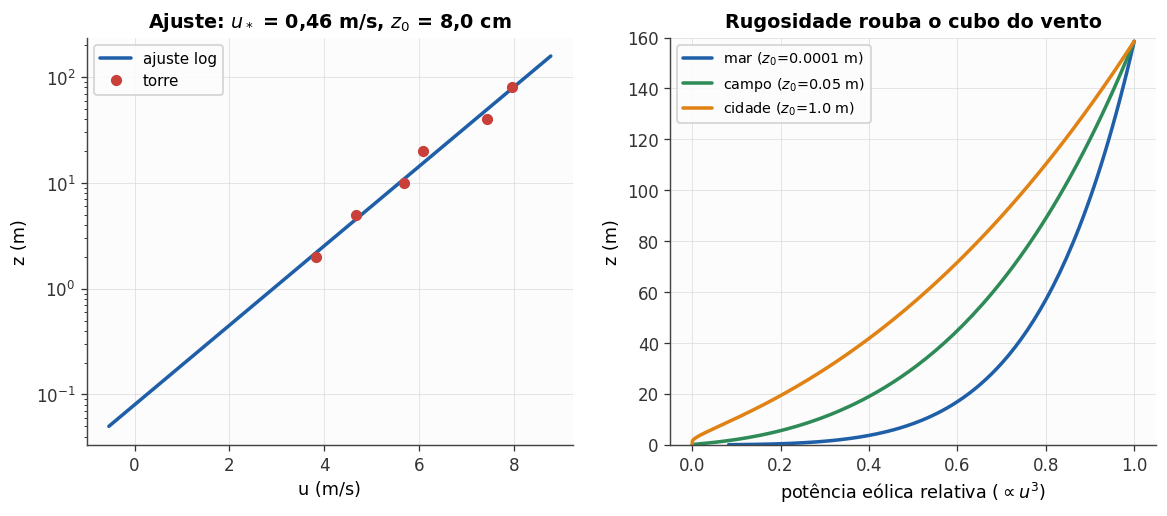

turbinas a 100-150 m fogem da rugosidade: o u³ da potencia faz cada
metro de torre valer dinheiro — o perfil log e engenharia, nao so teoria.


In [3]:
rng = np.random.default_rng(18)
z_torre = np.array([2.0, 5.0, 10.0, 20.0, 40.0, 80.0])
u_star_v, z0_v = 0.42, 0.05                     # "verdade" (grama alta)
u_obs = u_star_v/kv*np.log(z_torre/z0_v)*(1 + 0.03*rng.standard_normal(6))

# ajuste por regressão em ln(z)
A = np.polyfit(np.log(z_torre), u_obs, 1)
u_star, z0 = A[0]*kv, np.exp(-A[1]/A[0])

z_plot = np.logspace(np.log10(0.05), 2.2, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
ax1.semilogy(u_star/kv*np.log(z_plot/z0), z_plot, color=CORES['azul'],
             label='ajuste log')
ax1.plot(u_obs, z_torre, 'o', color=CORES['vermelho'], label='torre')
ax1.set(xlabel='u (m/s)', ylabel='z (m)',
        title=f'Ajuste: $u_*$ = {u_star:.2f} m/s, $z_0$ = {z0*100:.1f} cm'.replace('.', ','))
ax1.legend()
# potência eólica ~ u³
for z0_r, nome, cor in [(1e-4, 'mar', CORES['azul']), (0.05, 'campo', CORES['verde']),
                         (1.0, 'cidade', CORES['laranja'])]:
    u120 = u_star/kv*np.log(120/z0_r)
    perfil = u_star/kv*np.log(np.maximum(z_plot, z0_r*1.01)/z0_r)
    ax2.plot(perfil**3/np.max(perfil**3), z_plot, color=cor, label=f'{nome} ($z_0$={z0_r} m)')
ax2.set(xlabel='potência eólica relativa ($\\propto u^3$)', ylabel='z (m)', ylim=(0, 160),
        title='Rugosidade rouba o cubo do vento')
ax2.legend(fontsize=9)
plt.show()
print('turbinas a 100-150 m fogem da rugosidade: o u³ da potencia faz cada')
print('metro de torre valer dinheiro — o perfil log e engenharia, nao so teoria.')

## Caso 3 — O espectro $-5/3$

Kolmogorov (1941): no intervalo inercial a energia cai como $S(f) \propto f^{-5/3}$ — só análise dimensional com a taxa de dissipação $\varepsilon$ (T5). Sintetizamos um sinal turbulento e conferimos.

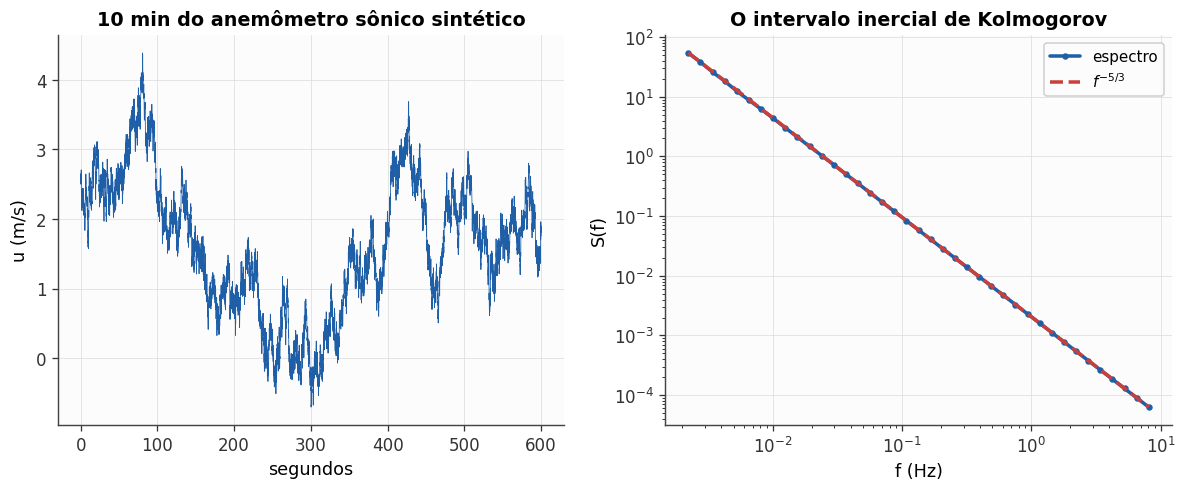

TKE = 0.32 m²/s² (so da componente u);
a cascata leva energia dos turbilhoes grandes (producao, ~z_i) aos
pequenos (dissipacao viscosa, ~mm) atraves do -5/3 — sem escala propria,
como as nuvens fractais do Cap. 6.


In [4]:
fs, T_reg = 20.0, 3600.0                        # 20 Hz por 1 h
n = int(fs*T_reg)
freqs = np.fft.rfftfreq(n, 1/fs)
amp = np.zeros_like(freqs)
m = freqs > 0
amp[m] = freqs[m]**(-5/6)                       # S ~ f^{-5/3} -> amplitude ~ f^{-5/6}
amp[freqs < 1/600] = amp[m][freqs[m] >= 1/600][0]   # produção em baixas f
fase = rng.uniform(0, 2*np.pi, freqs.size)
sinal = np.fft.irfft(amp*np.exp(1j*fase), n)
sinal = 2.0 + 0.8*sinal/np.std(sinal)          # vento médio 2 m/s + rajadas

S = np.abs(np.fft.rfft(sinal - sinal.mean()))**2/(fs*n)
# suaviza em bandas logarítmicas
fb = np.logspace(np.log10(2e-3), np.log10(9), 40)
Sb = [S[(freqs >= f1) & (freqs < f2)].mean() for f1, f2 in zip(fb[:-1], fb[1:])]
fc = np.sqrt(fb[:-1]*fb[1:])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax1.plot(np.arange(n)[:12000]/fs, sinal[:12000], color=CORES['azul'], lw=0.5)
ax1.set(xlabel='segundos', ylabel='u (m/s)', title='10 min do anemômetro sônico sintético')
ax2.loglog(fc, Sb, 'o-', ms=3, color=CORES['azul'], label='espectro')
ax2.loglog(fc, Sb[12]*(fc/fc[12])**(-5/3), '--', color=CORES['vermelho'],
           label='$f^{-5/3}$')
ax2.set(xlabel='f (Hz)', ylabel='S(f)', title='O intervalo inercial de Kolmogorov')
ax2.legend()
plt.show()
print(f'TKE = {0.5*np.var(sinal):.2f} m²/s² (so da componente u);')
print('a cascata leva energia dos turbilhoes grandes (producao, ~z_i) aos')
print('pequenos (dissipacao viscosa, ~mm) atraves do -5/3 — sem escala propria,')
print('como as nuvens fractais do Cap. 6.')

## Caso 4 — O jato noturno de Blackadar

Ao anoitecer a turbulência morre e o ar acima da inversão se **desacopla** do atrito. O vento, que estava sub-geostrófico, oscila inercialmente em torno de $\vec U_g$ (Cap. 10) — e fica **super-geostrófico** de madrugada: o jato de baixos níveis.

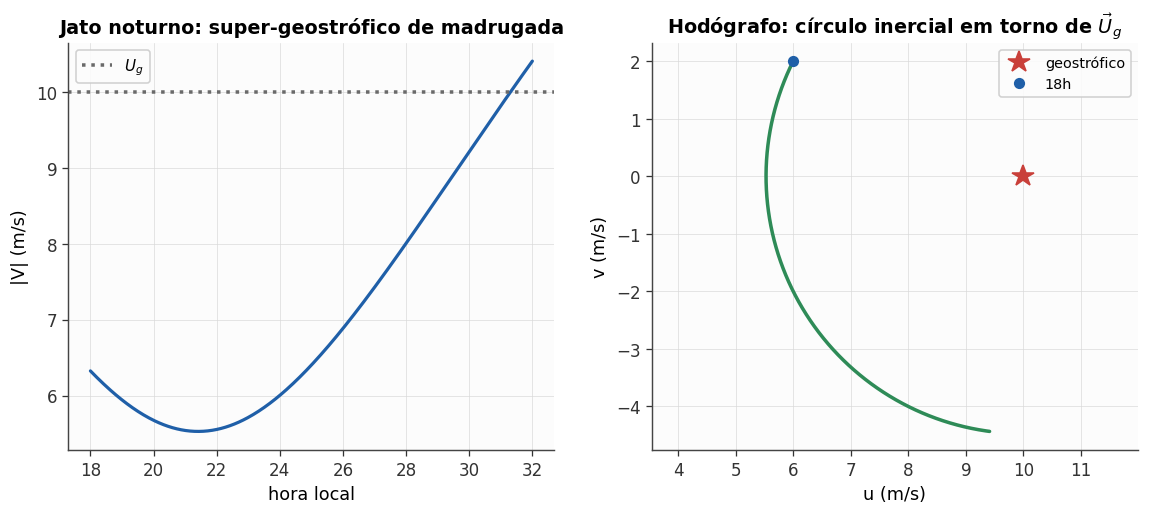

pico do jato: 10.4 m/s (1.04 U_g) ~14 h apos o desacoplamento;
e o jato que transporta umidade a noite e alimenta as tempestades
noturnas do centro do continente (La Plata! — e o Great Plains LLJ).


In [5]:
f = 2*Omega*np.sin(np.deg2rad(-15))            # baixas latitudes: período longo
Ug = 10.0
u0, v0 = 6.0, 2.0                              # fim de tarde: sub-geostrófico, cruzando isóbaras

def blackadar(t, y):
    u, v = y
    return [f*v, -f*(u - Ug)]                  # sem atrito após o pôr do sol

t_eval = np.linspace(0, 14*3600, 400)
s = solve_ivp(blackadar, [0, 14*3600], [u0, v0], t_eval=t_eval, rtol=1e-10)
vel = np.hypot(s.y[0], s.y[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
ax1.plot(t_eval/3600 + 18, vel, color=CORES['azul'], lw=2)
ax1.axhline(Ug, color=CORES['cinza'], ls=':', label='$U_g$')
ax1.set(xlabel='hora local', ylabel='|V| (m/s)',
        title='Jato noturno: super-geostrófico de madrugada')
ax1.legend()
ax2.plot(s.y[0], s.y[1], color=CORES['verde'])
ax2.plot(Ug, 0, '*', ms=14, color=CORES['vermelho'], label='geostrófico')
ax2.plot(u0, v0, 'o', color=CORES['azul'], label='18h')
ax2.set(xlabel='u (m/s)', ylabel='v (m/s)', title='Hodógrafo: círculo inercial em torno de $\\vec U_g$')
ax2.axis('equal'); ax2.legend(fontsize=9)
plt.show()
print(f'pico do jato: {vel.max():.1f} m/s ({vel.max()/Ug:.2f} U_g) '
      f'~{t_eval[np.argmax(vel)]/3600:.0f} h apos o desacoplamento;')
print('e o jato que transporta umidade a noite e alimenta as tempestades')
print('noturnas do centro do continente (La Plata! — e o Great Plains LLJ).')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap18_solucoes.ipynb`**.

**N1** — Varra a razão de Bowen (via $F_H^{max}$ de 50 a 400 W/m²) e a estabilidade $\gamma$ (2 a 8 K/km) no Caso 1 e mapeie o $z_i$ do fim da tarde; compare floresta × deserto.

**N2** — Com o perfil log ajustado no Caso 2, calcule a potência eólica disponível ($\propto \bar u^3$) a 60, 100 e 150 m de altura de cubo para os três terrenos; quanto se ganha elevando a torre de 100 para 150 m em cada um?

**N3** — Reamostre o sinal do Caso 3 a 1 Hz e 0,1 Hz e recalcule o espectro; o que acontece com o intervalo inercial e onde aparece aliasing?

**N4** — Trace o período e a amplitude do jato de Blackadar para latitudes 10°, 23,5°, 45° e 60°S; em que latitudes o pico acontece antes do amanhecer (quando o jato 'sobrevive' à noite)?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*